Angie Joya


Leer dataset seleccionado: acer.us.txt

In [16]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [17]:
path = os.path.join(os.getcwd(), "ibm.us.csv")
dataset = pd.read_csv(path)
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0


a) Graficar el promedio

In [18]:
dataset["promedioDia"] = (dataset["High"]+dataset["Low"])/2
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt,promedioDia
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0,6.37540
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0,6.36705
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0,6.36290
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0,6.25845
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0,6.12070


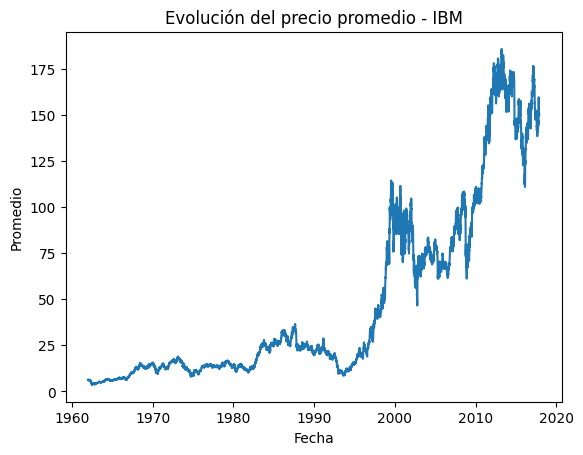

In [20]:
dataset["Date"] = pd.to_datetime(dataset["Date"])
plt.plot(dataset["Date"], dataset["promedioDia"], label = "Precio promedio por fecha")
plt.title("Evolución del precio promedio - IBM")
plt.xlabel("Fecha")
plt.ylabel("Promedio")
plt.show()

Normalización de los datos

In [ ]:
cols = ["Open", "High", "Low", "Close", "Volume", "OpenInt"]

mean = dataset[cols].mean()
std  = dataset[cols].std()

dataset[cols] = (dataset[cols] - mean) / std

In [ ]:
cols = ["Open", "High", "Low", "Close", "Volume", "OpenInt"]

# 1. Dividir (manteniendo orden temporal)
n = len(dataset)
train = dataset[:int(n*0.7)]
val   = dataset[int(n*0.7):int(n*0.85)]
test  = dataset[int(n*0.85):]

# 2. Calcular media y std solo en train
mean = train[cols].mean()
std  = train[cols].std()

# 3. Normalizar cada split usando esos valores
train[cols] = (train[cols] - mean) / std
val[cols]   = (val[cols]   - mean) / std
test[cols]  = (test[cols]  - mean) / std


Creación de ventanas

In [ ]:
sampling_rate = 1
sequence_length = 24 #120 días
delay = 1 #sampling_rate * 1
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)


División del dataset

In [ ]:
#70% train, 15% validation, 15% test
train, temp = train_test_split(dataset, test_size=0.30, random_state=42)
validation, test = train_test_split(temp, test_size=0.50, random_state=42)